# Analisis Sentimen Ulasan Film Menggunakan Metode Naïve Bayes

Nama : Queenly Vania Metanoia Napitupulu
NIM : A11.2024.15903
Kelas :A11.64405

Mata Kuliah : Machine Learning



# 1. Import Library

In [16]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# 2. Download NLTK Resources

In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

# 3. Load Dataset

In [3]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# 4. Exploratory Data Analysis (EDA)

In [4]:
df.shape

(50000, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [6]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [7]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [8]:
df.isnull().sum()

,0
review,0
sentiment,0


In [9]:
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


# 5. Distribusi Sentimen (Bar Chart)

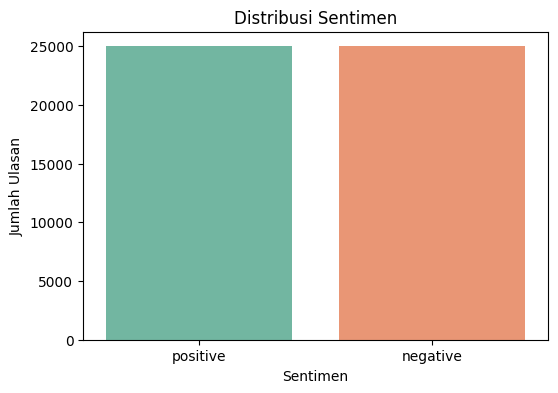

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="sentiment",
    hue="sentiment",
    palette="Set2",
    legend=False
)

plt.title("Distribusi Sentimen")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Ulasan")

plt.show()

### Insight
Dataset memiliki jumlah ulasan positif dan negatif yang seimbang, yaitu masing-masing sebanyak 25000 data. Kondisi ini sangat baik untuk proses pelatihan model karena dapat mengurangi kemungkinan model menjadi bias terhadap salah satu kelas.

# 6. Distribusi Sentimen (Pie Chart)

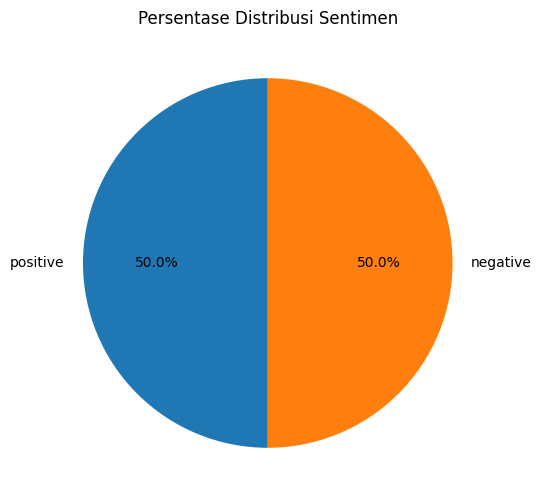

In [11]:
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Persentase Distribusi Sentimen")

plt.show()

### Insight

Diagram pie menunjukkan bahwa dataset terdiri dari 50% ulasan positif dan 50% ulasan negatif. Hal ini menunjukkan bahwa dataset telah memiliki distribusi kelas yang seimbang.

# 7. Analisis Panjang Ulasan

In [12]:
df["panjang_review"] = df["review"].apply(len)

df[["review", "panjang_review"]].head()

,review,panjang_review
0,One of the other reviewers has mentioned that ...,1761
1,A wonderful little production. <br /><br />The...,998
2,I thought this was a wonderful way to spend ti...,926
3,Basically there's a family where a little boy ...,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",1317


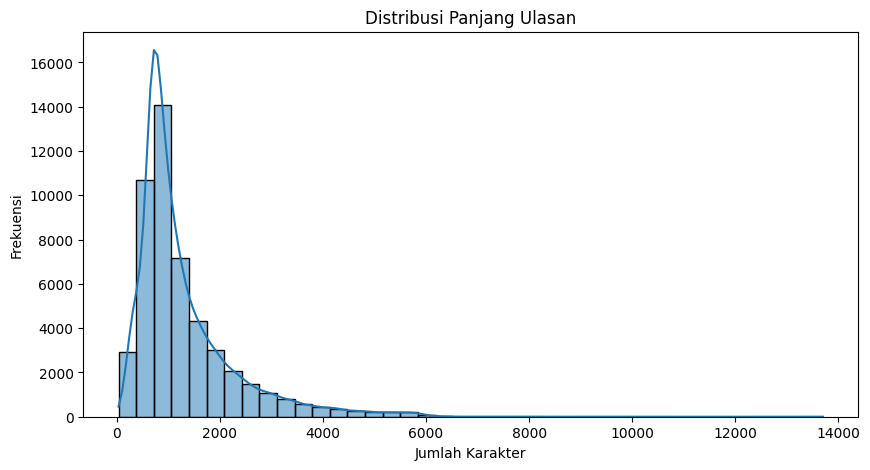

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="panjang_review",
    bins=40,
    kde=True
)

plt.title("Distribusi Panjang Ulasan")
plt.xlabel("Jumlah Karakter")
plt.ylabel("Frekuensi")

plt.show()

### Insight

Sebagian besar ulasan memiliki panjang sekitar 500–1500 karakter. Hal ini menunjukkan bahwa mayoritas pengguna memberikan ulasan yang cukup panjang sehingga mengandung informasi yang cukup untuk proses analisis sentimen.

# 8. WordCloud Ulasan Positif

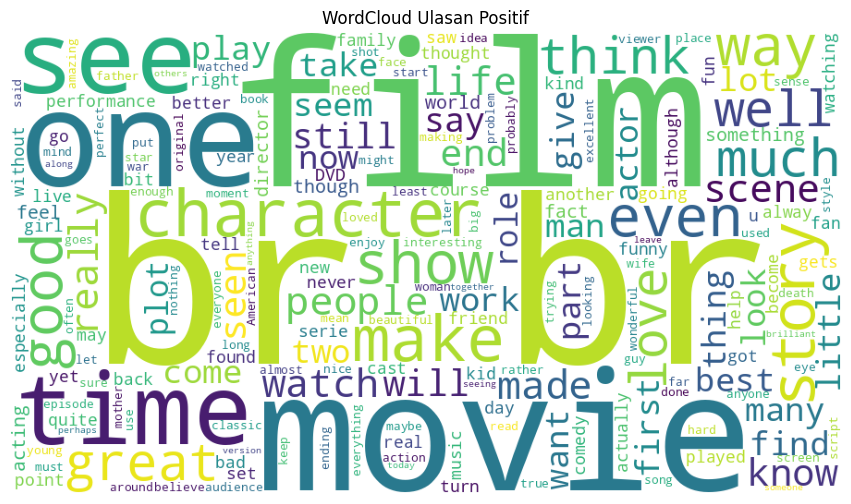

In [14]:
positive_text = " ".join(
    df[df["sentiment"] == "positive"]["review"]
)

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("WordCloud Ulasan Positif")

plt.show()

### Insight

WordCloud menunjukkan bahwa ulasan positif banyak mengandung kata-kata yang menggambarkan kepuasan penonton, seperti "great", "love", "best", dan "excellent".

#9. WordCloud Ulasan Negatif

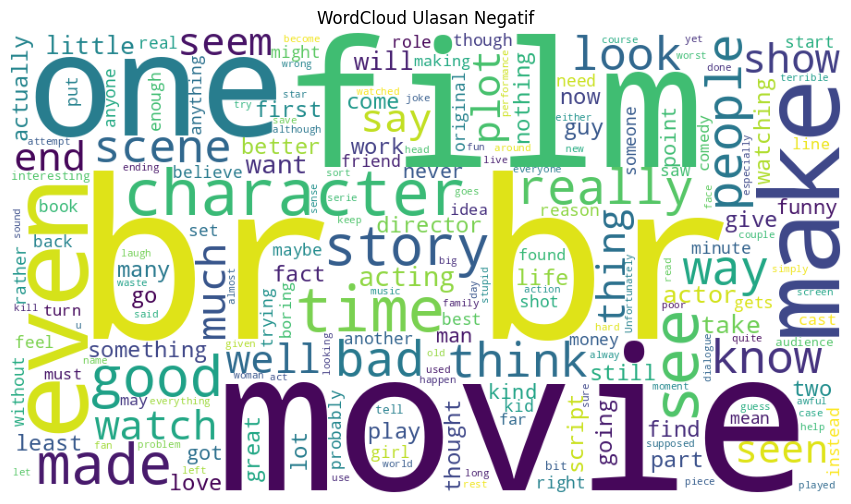

In [15]:
negative_text = " ".join(
    df[df["sentiment"] == "negative"]["review"]
)

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("WordCloud Ulasan Negatif")

plt.show()

### Insight

WordCloud ulasan negatif didominasi oleh kata-kata seperti "bad", "worst", "boring", dan "waste" yang menunjukkan ketidakpuasan penonton terhadap film.

# 10. 20 Kata yang Paling Sering Muncul

In [ ]:
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(df["review"])

word_counts = X.toarray().sum(axis=0)

words = vectorizer.get_feature_names_out()

word_freq = pd.DataFrame({
    "Kata": words,
    "Frekuensi": word_counts
})

word_freq = word_freq.sort_values(
    by="Frekuensi",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=word_freq,
    x="Frekuensi",
    y="Kata",
    palette="viridis"
)

plt.title("20 Kata yang Paling Sering Muncul")

plt.show()

### Insight

Grafik menunjukkan kata-kata yang paling sering muncul pada seluruh ulasan film. Setelah stopword dihilangkan, kata-kata yang muncul dapat memberikan gambaran umum mengenai topik yang paling sering dibahas oleh para penonton.

# Kesimpulan Exploratory Data Analysis (EDA)

Berdasarkan hasil eksplorasi data yang telah dilakukan, diperoleh beberapa kesimpulan sebagai berikut.

1. Dataset IMDb terdiri dari 50.000 ulasan film dengan distribusi kelas yang seimbang, yaitu masing-masing 25.000 ulasan positif dan 25.000 ulasan negatif.

2. Dataset tidak memiliki missing value maupun data duplikat sehingga kualitas data tergolong baik.

3. Sebagian besar ulasan memiliki panjang teks yang cukup sehingga informasi yang terkandung di dalamnya memadai untuk proses klasifikasi sentimen.

4. WordCloud menunjukkan adanya perbedaan kata-kata yang dominan pada ulasan positif dan ulasan negatif.

5. Berdasarkan hasil EDA, dataset layak digunakan sebagai data pelatihan model klasifikasi sentimen menggunakan algoritma Naïve Bayes maupun model pembanding lainnya.